In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import json

from matplotlib.ticker import MultipleLocator, LogLocator

with open("matplotlibrc.json") as f:
    mpl.rcParams.update(json.load(f))

In [3]:
def load_ler_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, dtype={"clifford_deformation": str})
    df["ler"] = df["alpha"] / (df["alpha"] + df["beta"])
    df["ler_var"] = df["alpha"] * df["beta"] / (df["alpha"] + df["beta"]) / (df["alpha"] + df["beta"]) / (df["alpha"] + df["beta"] + 1)
    df["ler_unc"] = np.sqrt(df["ler_var"])
    return df

In [4]:
cd_names = {
    "CSS":    ["000000000", "0000000000000000000000000", "0000000000000000000000000000000000000000000000000", "000000000000000000000000000000000000000000000000000000000000000000000000000000000", "0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"],
    "XZZX":   ["030303030", "0303030303030303030303030", "0303030303030303030303030303030303030303030303030", "030303030303030303030303030303030303030303030303030303030303030303030303030303030", "0303030303030303030303030303030303030303030303030303030303030303030303030303030303030303030303030303030303030303030303030"],
    "B-XZZX": ["033000330", "0333300300030300030033330", "0333333003030003030300030300030303000303003333330", "033333333003030300030303030003030300030303030003030300030303030003030300333333330", "0333333333300303030300030303030300030303030003030303030003030303000303030303000303030300030303030300030303030033333333330"],
    "Tiled":  ["033000330", "3303300000303303303300000", "3033033000000003303303033033000000003303303033033", "033033033000000000330330330033033033000000000330330330033033033000000000330330330", "3303303303300000000000303303303303303303303300000000000303303303303303303303300000000000303303303303303303303300000000000"],
}
cd_lers = {
    key: [None for _ in val] for key, val in cd_names.items()
}
cd_uncs = {
    key: [None for _ in val] for key, val in cd_names.items()
}
cd_samples = {
    key: [None for _ in val] for key, val in cd_names.items()
}

for L in [3,5,7,9,11]:
    file = f"../results/brute_force/ext_SC{L}_MHBD/results.csv"
    df = pd.read_csv(file, dtype={"clifford_deformation": str})
    pooled = df.groupby("clifford_deformation", as_index=False)[["alpha", "beta"]].sum()
    # each row carries a Beta(1, 1) prior (alpha + beta = shots + 2), so summing n rows
    # stacks n priors; subtract the n - 1 extras to get the pooled posterior
    n_rows = df.groupby("clifford_deformation").size().to_numpy()
    pooled["alpha"] -= n_rows - 1
    pooled["beta"] -= n_rows - 1

    # float64, not int64: the pooled counts reach ~1e11, so (alpha + beta) ** 2
    # silently overflows an int64 and the uncertainty comes out garbage
    a = pooled["alpha"].astype(float)
    b = pooled["beta"].astype(float)
    pooled["ler"] = a / (a + b)
    pooled["ler_unc"] = np.sqrt(a * b / (a + b) ** 2 / (a + b + 1))
    for cd_name, cds in cd_names.items():
        for i, cd in enumerate(cds):
            if cd in pooled["clifford_deformation"].values:
                row = pooled.loc[pooled["clifford_deformation"] == cd]
                display(row)
                cd_lers[cd_name][i] = row["ler"].values[0]
                cd_uncs[cd_name][i] = row["ler_unc"].values[0]
                cd_samples[cd_name][i] = np.log10(row["alpha"].values[0] + row["beta"].values[0] - 2)

,clifford_deformation,alpha,beta,ler,ler_unc
0,000000000,43772854,9956227148,0.004377,6.601609e-07


,clifford_deformation,alpha,beta,ler,ler_unc
1,030303030,39227081,9960772921,0.003923,6.250856e-07


,clifford_deformation,alpha,beta,ler,ler_unc
2,033000330,37219777,9962780225,0.003722,6.089437e-07


,clifford_deformation,alpha,beta,ler,ler_unc
2,033000330,37219777,9962780225,0.003722,6.089437e-07


,clifford_deformation,alpha,beta,ler,ler_unc
0,0000000000000000000000000,7401592,9992598410,0.00074,2.719580e-07


...

,clifford_deformation,alpha,beta,ler,ler_unc
2,0330330330000000003303303300330330330000000003...,80664,9999919338,0.000008,2.840129e-08


,clifford_deformation,alpha,beta,ler,ler_unc
0,0000000000000000000000000000000000000000000000...,209870,99999790132,0.000002,4.581152e-09


,clifford_deformation,alpha,beta,ler,ler_unc
1,0303030303030303030303030303030303030303030303...,67630,99999932372,6.763000e-07,2.600576e-09


,clifford_deformation,alpha,beta,ler,ler_unc
2,0333333333300303030300030303030300030303030003...,60369,99999939633,6.036900e-07,2.457010e-09


,clifford_deformation,alpha,beta,ler,ler_unc
3,3303303303300000000000303303303303303303303300...,90091,99999909911,9.009100e-07,3.001515e-09


5.39%, 5.30%, 8.31%, 11.61%, 12.03%


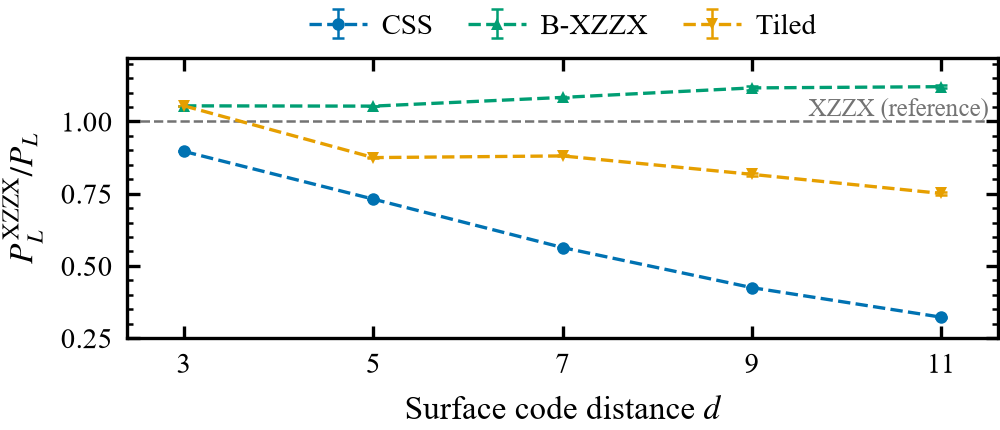

In [6]:
# PRX-ready version of the figure above.
reference = "XZZX"

x = np.array([3, 5, 7, 9, 11])
ler_ref = np.array(cd_lers[reference], dtype=float)
unc_ref = np.array(cd_uncs[reference], dtype=float)

# Okabe-Ito hues + a distinct marker each, so identity never rests on colour alone;
# the hue/marker per deformation is the one every figure in the paper uses. Tiled's
# orange sits close to XZZX's vermillion under deuteranopia, so there the marker
# carries the identity. The default matplotlib green/red pair fails deuteranopia.
STYLE = {
    "CSS":    dict(color="#0072B2", marker="o"),
    "B-XZZX": dict(color="#009E73", marker="^"),
    "Tiled":  dict(color="#E69F00", marker="v"),
}

fig, ax = plt.subplots(figsize=(3.4, 1.5))

# XZZX is the reference: the ratio is 1 by construction, so it is a rule, not a series
ax.axhline(1.0, color="0.45", ls="--", lw=0.6, zorder=1)
ax.text(11.5, 1, "XZZX (reference)", ha="right", va="bottom", fontsize=6, color="0.45")

for cd_name, style in STYLE.items():
    ler = np.array(cd_lers[cd_name], dtype=float)
    unc = np.array(cd_uncs[cd_name], dtype=float)
    y = ler_ref / ler
    yerr = y * np.sqrt((unc_ref / ler_ref) ** 2 + (unc / ler) ** 2)
    # B-XZZX and Tiled are the same deformation at d = 3, so their markers coincide
    dx = 0.08 if cd_name == "Tiled" else 0.0
    dx = 0
    if cd_name == "B-XZZX":
        print(', '.join(f"{v-1:.2%}" for v in y))
    bars = ax.errorbar(
        x + dx, y, yerr=yerr, ls="--", lw=0.8, ms=3, mew=0.0,
        capsize=1.5, elinewidth=0.6, label=cd_name, zorder=2, **style,
    )
    # mew=0 overrides capthick and would leave the caps zero-width, so set their
    # thickness on the caplines directly (same fix as in tables.ipynb)
    for cap in bars[1]:
        cap.set_markeredgewidth(0.6)

ax.set_xlabel("Surface code distance $d$")
ax.set_ylabel(r"$P_L^{\mathrm{XZZX}} / P_L$")
ax.set_xticks(x)
ax.set_xlim(2.4, 11.6)
ax.set_ylim(0.25, 1.22)
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.tick_params(which="both", top=True, right=True)

ax.legend(ncols=3, loc="lower center", bbox_to_anchor=(0.5, 1.0), borderaxespad=0.2, columnspacing=1.2, handletextpad=0.5)

fig.savefig("outputs/generalization/generalization.pdf", transparent=True)
plt.show()
